# Flatness-by-class overview

Interprets the two outputs of `compute_flatness_by_class.py`:
`flatness_by_clip.csv` (per-clip RMS energy + spectral flatness) and
`flatness_by_deployment.csv` (aggregated per `(deployment, label)` pair).

That script's docstring flags the real risk: a class's flatness score can
reflect real acoustic content, or it can mostly reflect which site/equipment
recorded it -- e.g. NRKW vs SRKW scoring wildly differently despite being
related killer whale ecotypes. This notebook checks that directly: for each
label, how much does its flatness score vary *across deployments* (site
signal) vs how separated are labels from each other (content signal)?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

pd.set_option("display.max_rows", 100)

## Parameters

In [2]:
data_dir = Path("../../data_raw/DCLDE_2027")
per_clip_path = data_dir / "flatness_by_clip.csv"
aggregated_path = data_dir / "flatness_by_deployment.csv"

## Load

In [3]:
per_clip = pd.read_csv(per_clip_path)
aggregated = pd.read_csv(aggregated_path)
print(f"{len(per_clip):,} per-clip rows")
print(f"{len(aggregated):,} (deployment, label) rows, {aggregated['label'].nunique()} labels, {aggregated['deployment'].nunique()} deployments")
aggregated.head()

5,927 per-clip rows
130 (deployment, label) rows, 10 labels, 32 deployments


,deployment,label,rms_mean_mean,rms_mean_std,rms_std_mean,rms_std_std,flatness_mean_mean,flatness_mean_std,flatness_std_mean,flatness_std_std,n_clips
0,BarkleyCanyon,HW,0.000807,0.000047,0.000033,0.000015,0.000130,0.000106,0.000145,0.000027,50
1,BarkleyCanyon,KW_und,0.000820,0.000021,0.000028,0.000012,0.000061,0.000065,0.000130,0.000038,50
2,BarkleyCanyon,OKW,0.000788,0.000008,0.000063,0.000014,0.000050,0.000037,0.000208,0.000189,50
3,BarkleyCanyon,SRKW,0.000764,0.000115,0.000052,0.000013,0.020030,0.141417,0.000128,0.000036,50
4,BarkleyCanyon,TKW,0.000769,0.000023,0.000069,0.000030,0.000051,0.000014,0.000139,0.000032,50


## Summary by label

For each label: its clip-count-weighted mean flatness/RMS across all
deployments, and the *unweighted* std of each deployment's mean across
deployments -- that second number is the site-signal check. A label whose
deployment means bounce around a lot (high `flatness_std_across_deployments`)
is a label whose score is being driven by where it was recorded, not what it
sounds like.

In [4]:
def label_summary(aggregated: pd.DataFrame) -> pd.DataFrame:
    """Weighted mean + cross-deployment std of flatness/RMS, one row per label."""
    rows = []
    for label, d in aggregated.groupby("label"):
        weights = d["n_clips"]
        rows.append({
            "label": label,
            "n_deployments": d["deployment"].nunique(),
            "total_clips": int(weights.sum()),
            "flatness_mean": (d["flatness_mean_mean"] * weights).sum() / weights.sum(),
            "flatness_std_across_deployments": d["flatness_mean_mean"].std(),
            "rms_mean": (d["rms_mean_mean"] * weights).sum() / weights.sum(),
            "rms_std_across_deployments": d["rms_mean_mean"].std(),
        })
    return pd.DataFrame(rows).sort_values("flatness_std_across_deployments", ascending=False).reset_index(drop=True)


summary = label_summary(aggregated)
summary

,label,n_deployments,total_clips,flatness_mean,flatness_std_across_deployments,rms_mean,rms_std_across_deployments
0,AB,19,811,0.232469,0.366084,0.003214,0.004655
1,NRKW,3,150,0.121406,0.115667,0.002767,0.004267
2,UndBio,7,247,0.124719,0.096251,0.001827,0.001481
3,KW_und,10,451,0.057189,0.076079,0.002542,0.006767
4,TKW,22,929,0.033590,0.074369,0.003013,0.002502
5,OKW,6,300,0.071853,0.073762,0.002108,0.002664
6,HW,12,561,0.039043,0.059383,0.002881,0.002128
7,candidate_background,32,1530,0.024829,0.050453,0.005816,0.008241
8,SRKW,17,848,0.037188,0.039579,0.003629,0.004073
9,SAR,2,100,0.023662,0.032012,0.012341,0.008023


The docstring's NRKW-vs-SRKW example shows up directly here: NRKW's
`flatness_std_across_deployments` is roughly 3x SRKW's despite both being
resident killer whale ecotypes -- NRKW's flatness score is much more
site-dependent than SRKW's.

## Label x deployment table

Every deployment mean for every label, color-graded per label (row) so
within-label site variation is visible independent of between-label
differences. Blank cells are (deployment, label) pairs with no sampled clips.

In [5]:
pivot = aggregated.pivot_table(index="label", columns="deployment", values="flatness_mean_mean")
pivot = pivot.loc[summary["label"]]  # ordered by flatness_std_across_deployments, worst first
pivot.style.background_gradient(cmap="viridis", axis=1).format(precision=3)

deployment,BarkleyCanyon,BoundaryPass,CarmanahPt,Cpe_Elz,Field_HTI,Field_SondTrap,HE_67391498,HE_67424266,HaroStraitNorth,HaroStraitSouth,KB_5354,KB_67383303,KB_67424266,LimeKiln,MS_5360,MS_671879205,MS_6897,NorthBc,Quin_Can,RB_335826997,RB_67424266,StrGeoN1,StrGeoN2,StrGeoS1,StrGeoS2,StraitofGeorgia,SwanChan,Tekteksen,WVanIsl,bush_point,orcasound_lab,port_townsend
label,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AB,nan,0.024,0.022,0.017,nan,nan,nan,nan,0.006,0.008,nan,nan,nan,0.039,nan,nan,nan,0.382,0.067,nan,nan,0.020,0.000,0.000,0.000,0.065,0.021,0.000,0.155,1.000,1.000,1.000
NRKW,nan,nan,0.002,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.233,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.129,nan,nan,nan
UndBio,0.000,0.047,0.102,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.103,nan,nan,nan,0.246,nan,nan,nan,nan,nan,nan,nan,0.012,nan,nan,0.217,nan,nan,nan
KW_und,0.000,0.025,nan,0.004,nan,nan,nan,nan,0.011,0.009,nan,nan,nan,0.073,nan,nan,nan,0.249,nan,nan,nan,nan,nan,nan,nan,0.029,nan,0.021,0.099,nan,nan,nan
TKW,0.000,0.006,0.021,0.044,nan,nan,0.000,0.000,nan,0.012,0.046,nan,0.000,nan,0.000,0.046,nan,0.295,0.018,0.000,0.200,0.000,0.020,0.000,0.000,0.001,0.000,nan,0.110,nan,nan,nan
OKW,0.000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.040,nan,nan,nan,nan,0.024,0.202,0.054,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.111,nan,nan,nan
HW,0.000,nan,0.002,0.013,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.089,nan,nan,nan,0.189,nan,nan,nan,nan,0.000,0.020,0.000,0.004,0.020,0.000,0.100,nan,nan,nan
candidate_background,0.000,0.009,0.002,0.033,0.122,0.000,0.000,0.000,0.007,0.011,0.045,0.000,0.000,0.029,0.000,0.013,0.002,0.230,0.056,0.000,0.000,0.000,0.000,0.000,0.000,0.019,0.000,0.000,0.142,0.008,0.043,0.001
SRKW,0.020,0.023,0.042,0.045,nan,nan,nan,nan,0.008,0.010,nan,nan,nan,0.063,nan,nan,nan,nan,nan,nan,nan,0.020,nan,0.020,0.020,0.043,0.000,0.001,0.097,0.043,0.159,0.021


### NRKW vs SRKW

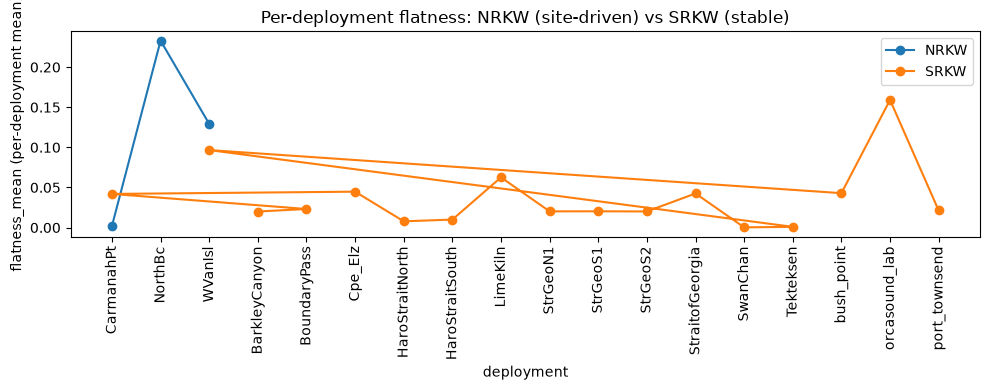

In [6]:
compare = aggregated[aggregated["label"].isin(["NRKW", "SRKW"])]

fig, ax = plt.subplots(figsize=(10, 4))
for label, d in compare.groupby("label"):
    d = d.sort_values("deployment")
    ax.plot(d["deployment"], d["flatness_mean_mean"], marker="o", label=label)
ax.set_ylabel("flatness_mean (per-deployment mean)")
ax.set_xlabel("deployment")
ax.tick_params(axis="x", rotation=90)
ax.legend()
ax.set_title("Per-deployment flatness: NRKW (site-driven) vs SRKW (stable)")
fig.tight_layout()

## Per-clip distribution by label

Pooling all deployments together per label, to see how much separation
survives once site variation is averaged out.

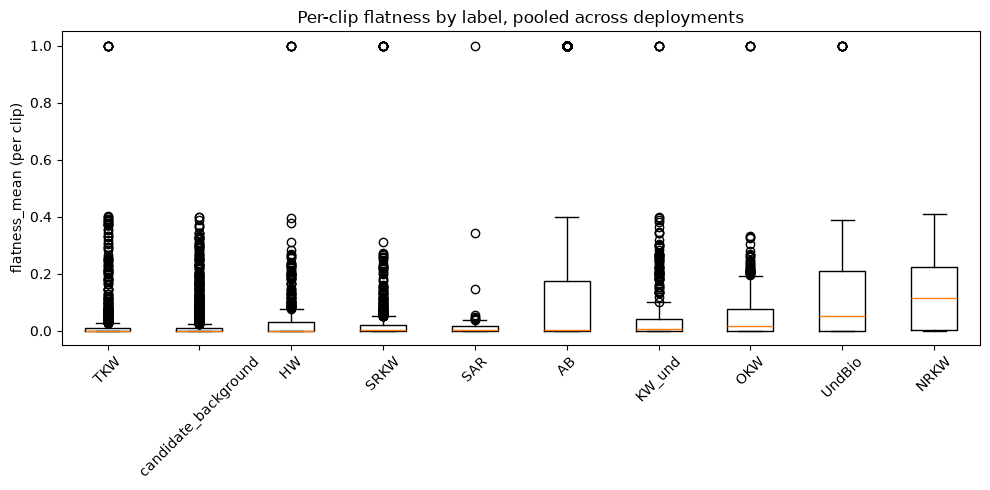

In [7]:
order = per_clip.groupby("label")["flatness_mean"].median().sort_values().index
data_by_label = [per_clip.loc[per_clip["label"] == label, "flatness_mean"] for label in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data_by_label, tick_labels=list(order))
ax.set_ylabel("flatness_mean (per clip)")
ax.set_title("Per-clip flatness by label, pooled across deployments")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()